The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


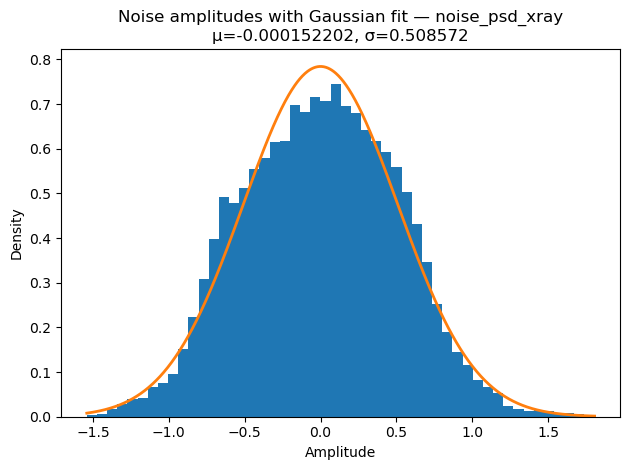

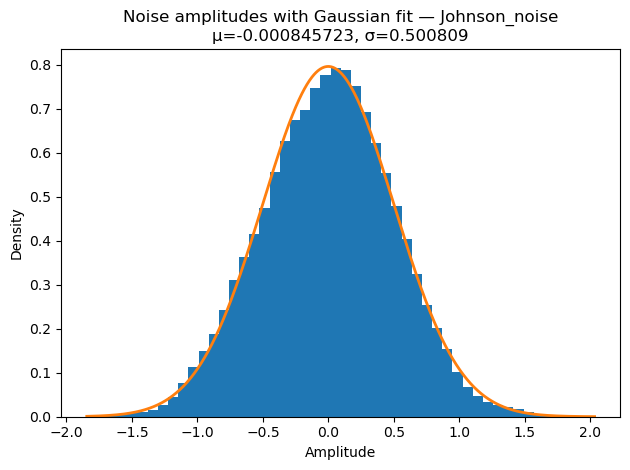

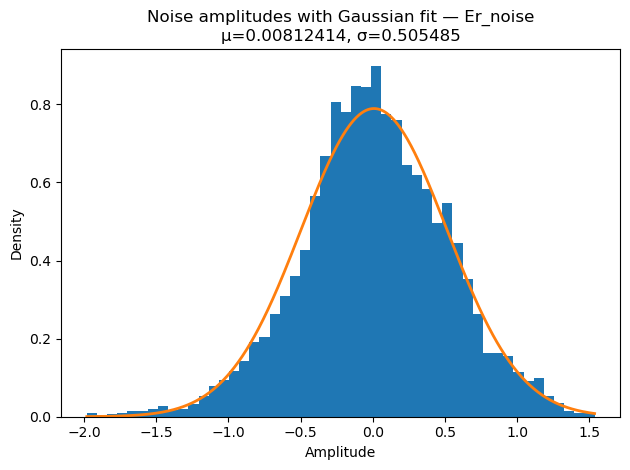

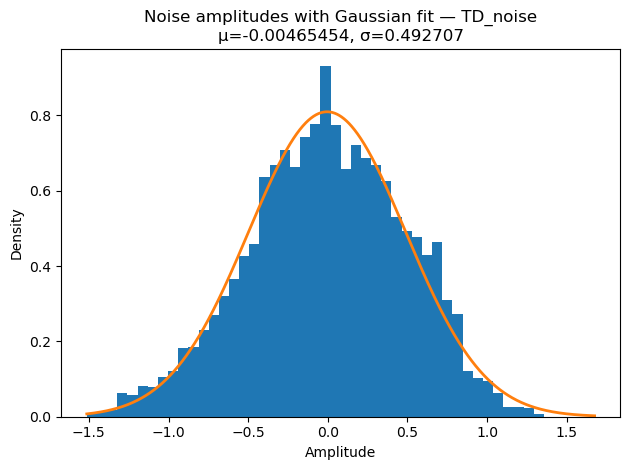

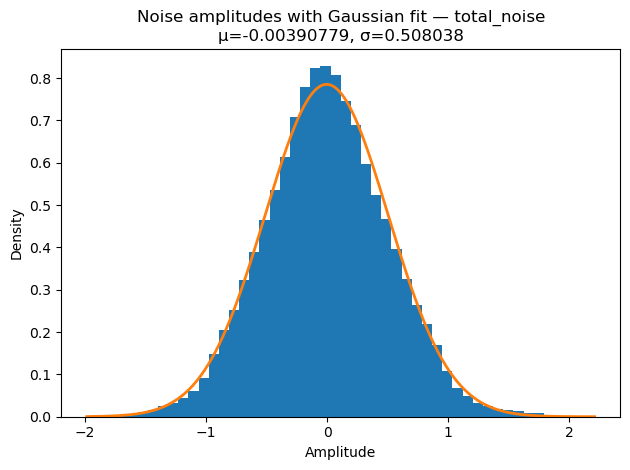

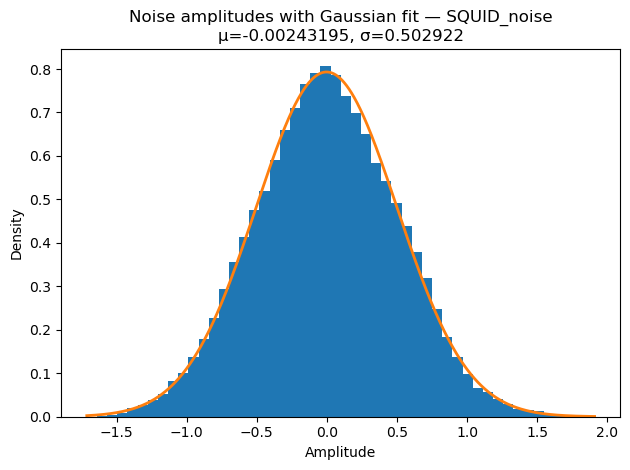


=== Summary (per noise PSD) ===
PSD                       mu         sigma  n_amps  (key)
noise_psd_xray  -0.000152202      0.508572  467233  (noise_type)
Johnson_noise   -0.000845723      0.500809  467233  (noise_type)
Er_noise          0.00812414      0.505485  467233  (noise_type)
TD_noise         -0.00465454      0.492707  467233  (noise_type)
total_noise      -0.00390779      0.508038  467233  (noise_type)
SQUID_noise      -0.00243195      0.502922  467233  (noise_type)


In [ ]:
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from TraceSimulator import NoiseGenerator
from trigger_study.wk23.OptimumFilter import *
# ---------- config helpers ----------
def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as f:
        return yaml.safe_load(f)

def set_noise_psd_path(config: dict, psd_path: str):
    """
    Update the config to point to the given PSD path.
    Tries a few common keys; creates 'noise_type' if nothing matches.
    """
    # Try nested structure first
    if isinstance(config.get("noise"), dict) and "psd_path" in config["noise"]:
        config["noise"]["psd_path"] = psd_path
        return config, "noise.psd_path"
    # Try flat keys
    if "noise_psd_path" in config:
        config["noise_psd_path"] = psd_path
        return config, "noise_psd_path"
    if "noise_type" in config:
        config["noise_type"] = psd_path
        return config, "noise_type"
    # Fallback: create a simple key
    config["noise_type"] = psd_path
    return config, "noise_type"

# ---------- user inputs ----------
yaml_path = "/home/dwong/DELight_mtr/trigger_study/wk22/standardized_flow_center/calibration_config.yaml"
sub_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/sub_ch_template.npy")
OF_psd = "/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy"
fs = 3_906_250  # Hz
trace_len = 500_000  # samples for noise generation

psd_paths = [
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/noise_psd_xray.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/Johnson_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/Er_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/TD_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/total_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/SQUID_noise.npy",
]

# ---------- load base config ----------
base_config = read_yaml_to_dict(yaml_path)

# ---------- run loop ----------
summary = []  # list of dicts with name, mu, sigma, key_used
for psd_path in psd_paths:
    # 1) update config in-memory
    config = yaml.safe_load(yaml.dump(base_config))  # deep copy via yaml round-trip
    config, key_used = set_noise_psd_path(config, psd_path)

    # 2) regenerate noise with this PSD
    ng = NoiseGenerator(config)
    noise_trace = ng.generate_noise(trace_len).astype(np.float32)

    # 3) build OptimumFilter with the same PSD
    noise_psd = np.load(OF_psd)
    worker = OptimumFilter(sub_template, noise_psd, fs)

    # 4) slide to get amplitudes
    amps, _ = worker.sliding_fit(noise_trace, hop=1, reanchor_every=None, chisq_mode="none")

    # 5) fit Gaussian to amplitudes
    mu, sigma = norm.fit(amps)

    # 6) histogram + Gaussian curve (one chart per config, no explicit colors/styles)
    counts, bins, patches = plt.hist(amps, bins=50, density=True)
    x = np.linspace(float(np.min(amps)), float(np.max(amps)), 1000)
    pdf = norm.pdf(x, mu, sigma)
    plt.plot(x, pdf, linewidth=2)
    fname = os.path.splitext(os.path.basename(psd_path))[0]
    plt.xlabel("Amplitude")
    plt.ylabel("Density")
    plt.title(f"Noise amplitudes with Gaussian fit — {fname}\nμ={mu:.6g}, σ={sigma:.6g}")
    plt.tight_layout()
    plt.show()

    # 7) collect summary
    summary.append({
        "psd_name": fname,
        "psd_path": psd_path,
        "config_key": key_used,
        "mu": float(mu),
        "sigma": float(sigma),
        "n_amps": int(len(amps)),
    })

# ---------- print summary ----------
print("\n=== Summary (per noise PSD) ===")
w_name = max(len(s["psd_name"]) for s in summary)
w_sigma = 12
w_mu = 12
print(f"{'PSD':{w_name}}  {'mu':>{w_mu}}  {'sigma':>{w_sigma}}  n_amps  (key)")
for s in summary:
    print(f"{s['psd_name']:{w_name}}  {s['mu']:>{w_mu}.6g}  {s['sigma']:>{w_sigma}.6g}  {s['n_amps']:>6d}  ({s['config_key']})")


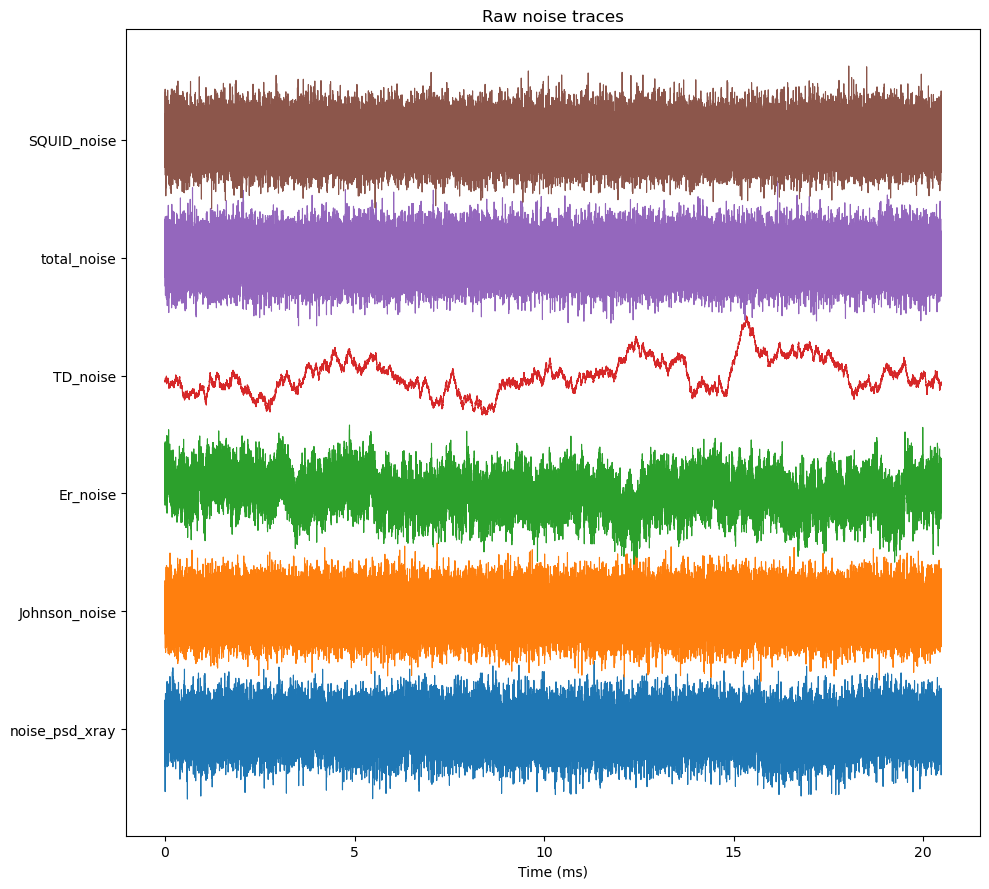

In [5]:
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
from TraceSimulator import NoiseGenerator

# ---------- helpers ----------
def read_yaml_to_dict(file_path):
    with open(file_path, "r") as f:
        return yaml.safe_load(f)

def set_noise_psd_path(config, psd_path):
    """Update the config to point to the given PSD path."""
    if isinstance(config.get("noise"), dict) and "psd_path" in config["noise"]:
        config["noise"]["psd_path"] = psd_path
    elif "noise_psd_path" in config:
        config["noise_psd_path"] = psd_path
    elif "noise_type" in config:
        config["noise_type"] = psd_path
    else:
        config["noise_type"] = psd_path
    return config

# ---------- user inputs ----------
yaml_path = "/home/dwong/DELight_mtr/trigger_study/wk22/standardized_flow_center/calibration_config.yaml"
fs = 3_906_250  # Hz
trace_len = 80_000  # samples for noise generation

psd_paths = [
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/noise_psd_xray.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/Johnson_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/Er_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/TD_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/total_noise.npy",
    "/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd/SQUID_noise.npy",
]

# ---------- load base config ----------
base_config = read_yaml_to_dict(yaml_path)

# ---------- generate and plot noise ----------
relative_spacing = 7.0  # vertical spacing between traces
use_zscore = True       # normalize each trace

traces, labels = [], []

for psd_path in psd_paths:
    # Update config for this PSD
    config = yaml.safe_load(yaml.dump(base_config))
    config = set_noise_psd_path(config, psd_path)

    # Generate noise
    ng = NoiseGenerator(config)
    trace = ng.generate_noise(trace_len).astype(np.float32)

    # Normalize if desired
    if use_zscore:
        trace = (trace - np.mean(trace)) / (np.std(trace) or 1.0)

    traces.append(trace)
    labels.append(os.path.splitext(os.path.basename(psd_path))[0])

# ---------- stacked plot ----------
if traces:
    n = len(traces)
    min_len = min(len(t) for t in traces)
    time_ms = np.arange(min_len) / fs * 1e3

    plt.figure(figsize=(10, 1.5 * n))
    for i, t in enumerate(traces):
        plt.plot(time_ms, t[:min_len] + i * relative_spacing, lw=0.8)

    plt.yticks([i * relative_spacing for i in range(n)], labels)
    plt.xlabel("Time (ms)")
    plt.title("Raw noise traces")
    plt.tight_layout()
    plt.show()


In [2]:
#!/usr/bin/env python3
import numpy as np
from pathlib import Path

# Configuration
fs = 3_906_250.0  # Hz
sub_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/sub_ch_template.npy")
N = sub_template.size
print(f"Using N={N}, fs={fs}")

# Paths
src_dir = Path("/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd_generate")
dst_dir = Path("/home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd_filter")
dst_dir.mkdir(parents=True, exist_ok=True)

def psd_to_rfftbins(freq_psd, N, fs, loglog=True):
    """Convert uneven-grid PSD (2D array of [f, S(f)]) to one-sided PSD
    sampled on rFFT bin centers for (N, fs)."""
    arr = np.asarray(freq_psd)
    if arr.ndim != 2 or 2 not in arr.shape:
        raise ValueError(f"expected 2D [f,S] array; got shape {arr.shape}")

    if arr.shape[1] == 2:
        f_in, S_in = arr[:, 0], arr[:, 1]
    else:  # (2, K)
        f_in, S_in = arr[0, :], arr[1, :]

    # sanitize
    mask = np.isfinite(f_in) & np.isfinite(S_in) & (f_in >= 0)
    f_in, S_in = f_in[mask], S_in[mask]
    order = np.argsort(f_in)
    f_in, S_in = f_in[order], S_in[order]

    # rFFT bins for template length N and sampling rate fs
    f_bins = np.fft.rfftfreq(int(N), d=1.0/float(fs))  # length N//2+1

    # clamp outside band to edge values; interpolate inside
    if loglog:
        eps = np.finfo(float).tiny
        S_safe = np.clip(S_in, eps, None)
        out = np.empty_like(f_bins)
        below = f_bins <= f_in[0]
        above = f_bins >= f_in[-1]
        mid = (~below) & (~above)
        out[below] = S_in[0]
        out[above] = S_in[-1]
        out[mid] = np.exp(np.interp(np.log(f_bins[mid] + eps),
                                     np.log(f_in + eps),
                                     np.log(S_safe)))
    else:
        out = np.interp(f_bins, f_in, S_in, left=S_in[0], right=S_in[-1])

    bad = ~np.isfinite(out) | (out <= 0)
    if bad.any():
        out[bad] = np.maximum(S_in[-1], np.finfo(float).tiny)
    return out

# Process all npy files in the source dir
for npy_path in src_dir.glob("*.npy"):
    print(f"Processing {npy_path.name}...")
    try:
        freq_psd = np.load(npy_path, allow_pickle=True)
        print(freq_psd.shape)
        psd_1d = psd_to_rfftbins(freq_psd, N, fs)
        out_path = dst_dir / npy_path.name
        np.save(out_path, psd_1d)
        print(f"  Saved 1D PSD -> {out_path} ({psd_1d.shape})")
    except Exception as e:
        print(f"  [ERROR] {npy_path.name}: {e}")

print(f"\n✅ Done! Converted PSDs saved in {dst_dir}")


Using N=32768, fs=3906250.0
Processing noise_psd_xray.npy...
(2, 16385)
  Saved 1D PSD -> /home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd_filter/noise_psd_xray.npy ((16385,))
Processing SQUID_noise.npy...
(2, 16385)
  Saved 1D PSD -> /home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd_filter/SQUID_noise.npy ((16385,))
Processing Er_noise.npy...
(2, 16385)
  Saved 1D PSD -> /home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd_filter/Er_noise.npy ((16385,))
Processing TD_noise.npy...
(2, 16385)
  Saved 1D PSD -> /home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd_filter/TD_noise.npy ((16385,))
Processing total_noise.npy...
(2, 16385)
  Saved 1D PSD -> /home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd_filter/total_noise.npy ((16385,))
Processing Johnson_noise.npy...
(2, 16385)
  Saved 1D PSD -> /home/dwong/DELight_mtr/trigger_study/wk23/new_noise_psd_filter/Johnson_noise.npy ((16385,))

✅ Done! Converted PSDs saved in /home/dwong/DELight_mtr/trigger_study/wk2